# Services — Bayesian sparse 4-variable BVAR with stochastic volatility and model-based outliers

This is the fourth model of the **Headline inflation suite**.

The economic specification follows **ECB Working Paper 374 (2004)**. Services is the important exception among the three non-energy component models: the selected euro-area specification is a genuine **BVAR**, not a dynamic single equation.

The system contains four endogenous monthly series:

1. HICP services;
2. compensation per employee;
3. producer prices of consumer goods;
4. HICP unprocessed food.

The selected common lag set is:

\[
\{1,2,3,4,5,12\}.
\]

Lags 6–11 are fixed exactly to zero in every equation and every posterior draw.

WP374 motivates the inclusion of unprocessed-food prices by their effect on restaurant prices, which are an important part of services. For forecast evaluation, the paper conditions on observed wages and producer prices and uses the separately forecast unprocessed-food path from its Unprocessed Food model.

Our production implementation preserves the **WP374 economic system and sparse lag structure**, but uses the validated Bayesian machinery of the Energy suite / ECB WP3062 project implementation:

- Energy-suite Minnesota calibration;
- stochastic volatility;
- model-based transitory outliers;
- Durbin–Koopman treatment of ragged-edge endogenous observations;
- shared forecast and registry contracts.

The historical WP374 BVAR hyperparameters are retained as a reference only; they are not silently substituted for the Energy-suite production prior.

## Econometric representation

Let

\[
x_t =
\begin{pmatrix}
\Delta\log I^{SERV}_t\\
\Delta\log WAGE_t\\
\Delta\log PPI^{CONS}_t\\
\Delta\log I^{UF}_t
\end{pmatrix}.
\]

The selected system is

\[
x_t
=
c+
A_1x_{t-1}+
A_2x_{t-2}+
A_3x_{t-3}+
A_4x_{t-4}+
A_5x_{t-5}+
A_{12}x_{t-12}
+\nu_t,
\]

with

\[
A_6=A_7=\cdots=A_{11}=0.
\]

The 12th lag supplies the seasonal structure, so the selected Services BVAR does **not** add monthly seasonal dummies.

The covariance layer is the same as in the Energy suite:

\[
A\nu_t=o_t\odot\Lambda_t^{1/2}\varepsilon_t,
\qquad
\varepsilon_t\sim N(0,I),
\]

with stochastic volatility and transitory model-based outliers.

All four series are endogenous. This matters for the current vintage: missing wage/PPI observations at the ragged edge are latent endogenous states and can therefore be handled coherently by the DK smoother instead of being filled as exogenous assumptions.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

import os
import sys
from dataclasses import asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/ and src/.")


env_root = os.environ.get("BVAR_PROJECT_ROOT")
PROJECT_ROOT = (
    Path(env_root).expanduser().resolve()
    if env_root
    else find_project_root(Path.cwd())
)

MODEL_DIR = PROJECT_ROOT / "src" / "model"
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

from headline_bvar_model import (
    BVARSVOPriorConfig,
    SamplerConfig,
    compare_services_scenario_to_wp374,
    forecast_headline_component,
    headline_component_contract_table,
    headline_component_spec,
    headline_forecast_horizon_table,
    headline_native_condition_path,
    headline_native_nowcast_summary_table,
    headline_panel_audit,
    headline_scenario_impact_table,
    headline_series_construction_table,
    headline_transformation_table,
    load_headline_component_panel,
    native_model_differences,
    prepare_headline_component,
    resolve_headline_component_dataset,
    run_headline_bvar,
    sparse_lag_restriction_table,
    wp374_services_reference_table,
    wp374_services_response_benchmark_table,
)

from headline_bvar_plot import (
    plot_headline_hicp_forecast_fan,
    plot_headline_model_differences,
    plot_headline_native_levels,
    plot_headline_scenario_impact,
)

from energy_bvar_model import (
    coefficient_posterior_table,
    mcmc_diagnostics,
    posterior_predictive_statistics,
    residual_diagnostic_table,
    stability_diagnostics,
    stationarity_tests,
)

from energy_bvar_plot import (
    plot_chain_acf_grid,
    plot_coefficient_heatmap,
    plot_outlier_probabilities,
    plot_phi_and_outlier_priors,
    plot_posterior_predictive_check,
    plot_posterior_volatility,
    plot_spectral_radius,
    plot_standardized_residuals,
    plot_trace_grid,
    style_numeric_table,
)

try:
    from energy_bvar_io import save_energy_bvar_result
except ImportError:
    save_energy_bvar_result = None


COMPONENT = "services"
SPEC = headline_component_spec(COMPONENT)

# None -> data/processed. During development this can point to a scratch build.
DATA_ROOT = None
VINTAGE = None

QUICK_TEST = False
FORECAST_HORIZON = 18
FORECAST_DRAWS = 200 if QUICK_TEST else 1_000
SAVE_RESULTS = False

# Production prior = validated Energy-suite calibration.
PRIOR_CONFIG = BVARSVOPriorConfig(
    lambda1=0.20,
    lambda2=0.50,
    lambda3=1.00,
    lambda4=10.0,
    a_prior_var=10.0,
    phi_prior_mean=0.02,
    phi_prior_df=10.0,
    h0_var=4.0,
    outlier_mean_frequency=1.0 / 48.0,
    outlier_prior_observations=120.0,
    outlier_grid_min=2.0,
    outlier_grid_max=20.0,
    outlier_grid_step=1.0,
    ksc_offset_scale=1e-6,
)

SAMPLER_CONFIG = SamplerConfig(
    reps=300 if QUICK_TEST else 6_000,
    burn=150 if QUICK_TEST else 3_000,
    thin=1,
    seed=42,
    max_stability_tries=1_000,
    progress_every=0 if QUICK_TEST else 500,
)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("COMPONENT:", COMPONENT)
print("Variables:", SPEC["variables"])
print("Maximum companion lag p:", SPEC["p"])
print("Active common lags:", SPEC["active_lags"])
print("Implementation:", SPEC["implementation_mode"])

PROJECT_ROOT: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy
COMPONENT: services
Variables: ['hicp_services', 'compensation_per_employee', 'ppi_consumer_goods', 'hicp_unprocessed_food']
Maximum companion lag p: 12
Active common lags: [1, 2, 3, 4, 5, 12]
Implementation: bayesian_sparse_bvar12_sv_outlier_exact_wp374_lag_structure


## 2. WP374 contract versus production Bayesian contract

In [2]:
display(wp374_services_reference_table())
display(headline_component_contract_table())
display(headline_transformation_table(COMPONENT))

,WP374,production
item,,
model_class,BVAR,BVAR-SV-outlier
variables,HICP services; compensation per employee; PPI ...,HICP services; compensation per employee; PPI ...
common_lags,"1,2,3,4,5,12","1,2,3,4,5,12 (exact fixed-zero restriction oth..."
tightness,0.1,0.2
cross_variable_weight,0.9,0.5
lag_decay,0.1,1.0
volatility,constant,stochastic volatility + transitory outliers


,label,dataset_file,target,paper_model_class,paper_lag_structure,active_lags,implementation_mode,production_ready,production_blocker
component,,,,,,,,,
unprocessed_food,Unprocessed food,unprocessed_food_monthly.csv,hicp_unprocessed_food,dynamic single equation / autoregression,"HICP unprocessed food L1, L10, L12 + 11 monthl...",None,dense_bayesian_ar12_shrinkage_approximation,True,None
processed_food,Processed food,processed_food_monthly.csv,hicp_processed_food,dynamic single equation,HICP PF L1-L4; food commodities L2; wages L0-L...,"[1, 2, 3, 4]",bayesian_arx4_sv_outlier_exact_wp374_lag_struc...,True,None
neig,Non-energy industrial goods,neig_monthly.csv,hicp_neig,dynamic single equation,"HICP NEIG L1,L6,L12; PPI consumer goods L1; wa...","[1, 6, 12]",bayesian_sparse_arx12_sv_outlier_exact_wp374_l...,True,None
services,Services,services_monthly.csv,hicp_services,BVAR,Services/wages/PPI consumer goods/unprocessed ...,"[1, 2, 3, 4, 5, 12]",bayesian_sparse_bvar12_sv_outlier_exact_wp374_...,True,None


,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags
native_series,,,,,,,
hicp_services,target,HICP index,logdiff,log(hicp_services),Δlog(hicp_services),state__hicp_services,"[1, 2, 3, 4, 5, 12]"
compensation_per_employee,driver,index,logdiff,log(compensation_per_employee),Δlog(compensation_per_employee),state__compensation_per_employee,"[1, 2, 3, 4, 5, 12]"
ppi_consumer_goods,driver,PPI index,logdiff,log(ppi_consumer_goods),Δlog(ppi_consumer_goods),state__ppi_consumer_goods,"[1, 2, 3, 4, 5, 12]"
hicp_unprocessed_food,driver,HICP index,logdiff,log(hicp_unprocessed_food),Δlog(hicp_unprocessed_food),state__hicp_unprocessed_food,"[1, 2, 3, 4, 5, 12]"


WP374 reports that the selected Services BVAR minimised its recursive RMSE with historical Minnesota hyperparameters:

```text
tightness = 0.1
cross-variable weight = 0.9
lag decay = 0.1
```

Those values describe the **2004 forecasting exercise**. They are not the production prior used here.

The current project deliberately harmonises Bayesian machinery with the Energy suite:

```text
lambda1 = 0.20
lambda2 = 0.50
lambda3 = 1.00
+ stochastic volatility
+ model-based outliers
```

Thus:

> **WP374 determines the Services variables and lag structure; the Energy suite determines the modern Bayesian estimation machinery.**

## 3. Load and audit the native Services panel

In [3]:
DATASET_PATH = resolve_headline_component_dataset(
    PROJECT_ROOT,
    COMPONENT,
    vintage=VINTAGE,
    data_root=DATA_ROOT,
)
VINTAGE_USED = DATASET_PATH.parent.name

native_levels = load_headline_component_panel(DATASET_PATH, COMPONENT)

print("Dataset:", DATASET_PATH)
print("Vintage:", VINTAGE_USED)

display(headline_series_construction_table(DATASET_PATH, COMPONENT))
display(headline_panel_audit(native_levels, COMPONENT))

Dataset: C:\Users\kelyan.gane\Project\Python\Bayesian_model\bvar-energy\data\processed\20260811\services_monthly.csv
Vintage: 20260811


,dataset_file,role,native_unit,transform,state_level,model_change,state_variable,paper_active_lags,paper_model_class,paper_lag_structure,implementation_mode
native_series,,,,,,,,,,,
hicp_services,services_monthly.csv,target,HICP index,logdiff,log(hicp_services),Δlog(hicp_services),state__hicp_services,"[1, 2, 3, 4, 5, 12]",BVAR,Services/wages/PPI consumer goods/unprocessed ...,bayesian_sparse_bvar12_sv_outlier_exact_wp374_...
compensation_per_employee,services_monthly.csv,driver,index,logdiff,log(compensation_per_employee),Δlog(compensation_per_employee),state__compensation_per_employee,"[1, 2, 3, 4, 5, 12]",BVAR,Services/wages/PPI consumer goods/unprocessed ...,bayesian_sparse_bvar12_sv_outlier_exact_wp374_...
ppi_consumer_goods,services_monthly.csv,driver,PPI index,logdiff,log(ppi_consumer_goods),Δlog(ppi_consumer_goods),state__ppi_consumer_goods,"[1, 2, 3, 4, 5, 12]",BVAR,Services/wages/PPI consumer goods/unprocessed ...,bayesian_sparse_bvar12_sv_outlier_exact_wp374_...
hicp_unprocessed_food,services_monthly.csv,driver,HICP index,logdiff,log(hicp_unprocessed_food),Δlog(hicp_unprocessed_food),state__hicp_unprocessed_food,"[1, 2, 3, 4, 5, 12]",BVAR,Services/wages/PPI consumer goods/unprocessed ...,bayesian_sparse_bvar12_sv_outlier_exact_wp374_...


,role,unit,first_observed,last_observed,n_calendar,n_observed,n_missing,missing_share
series,,,,,,,,
hicp_services,target,HICP index,1999-12-01,2026-07-01,320,320,0,0.000000
compensation_per_employee,endogenous_auxiliary,index,2000-03-01,2026-03-01,320,313,7,0.021875
ppi_consumer_goods,endogenous_auxiliary,PPI index,2000-01-01,2026-06-01,320,318,2,0.006250
hicp_unprocessed_food,endogenous_auxiliary,HICP index,1999-12-01,2026-07-01,320,320,0,0.000000


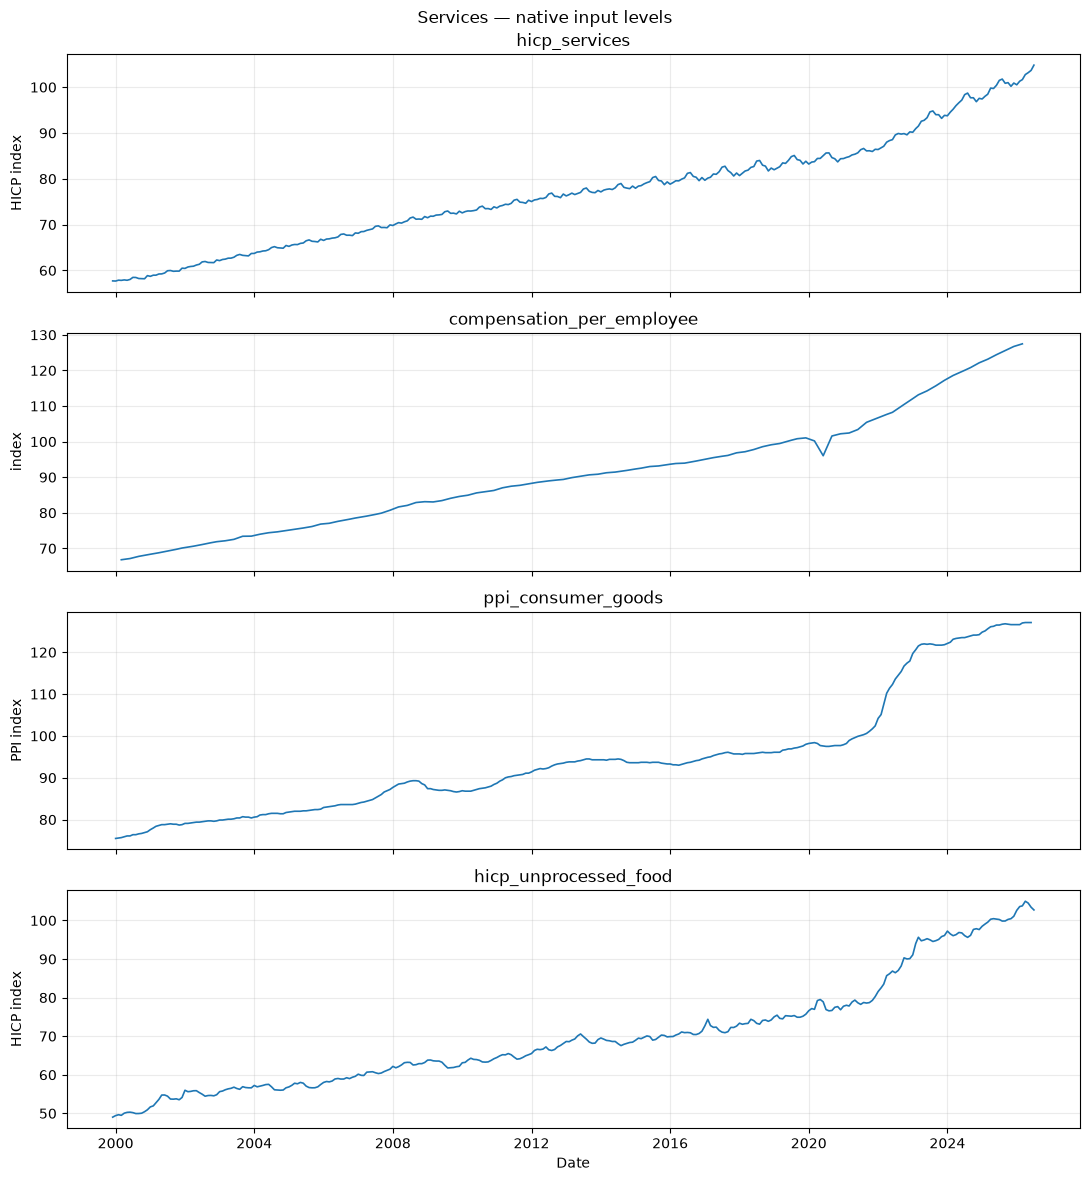

In [4]:
plot_headline_native_levels(
    native_levels,
    component_label=SPEC["label"],
    units=SPEC["units"],
)
plt.show()

### Current-frequency interpretation

The workbook/builder preserves native release frequencies upstream. Compensation per employee is originally quarterly and is linearly interpolated to monthly frequency in the data-construction layer, following WP374. Crucially, the builder does not extrapolate beyond the latest published quarter.

For Services this does **not** require an ad-hoc forecast fill: wages, PPI and unprocessed food are endogenous in the BVAR. Missing trailing values therefore remain missing observations. Parameter estimation uses the latest balanced block; the subsequent forecast/nowcast step conditions on all observed ragged-edge values and uses the DK smoother to draw the genuinely missing endogenous cells jointly.

## 4. Model-space transformations

,count,mean,std,min,25%,50%,75%,max
hicp_services,319.0,0.001871,0.005394,-0.012889,-0.000922,0.002301,0.005285,0.014290
compensation_per_employee,312.0,0.002071,0.002584,-0.014491,0.001359,0.001862,0.002727,0.018934
ppi_consumer_goods,317.0,0.001643,0.003230,-0.010245,0.000000,0.001195,0.002381,0.024806
hicp_unprocessed_food,319.0,0.002319,0.007838,-0.025802,-0.002539,0.002102,0.006723,0.033969


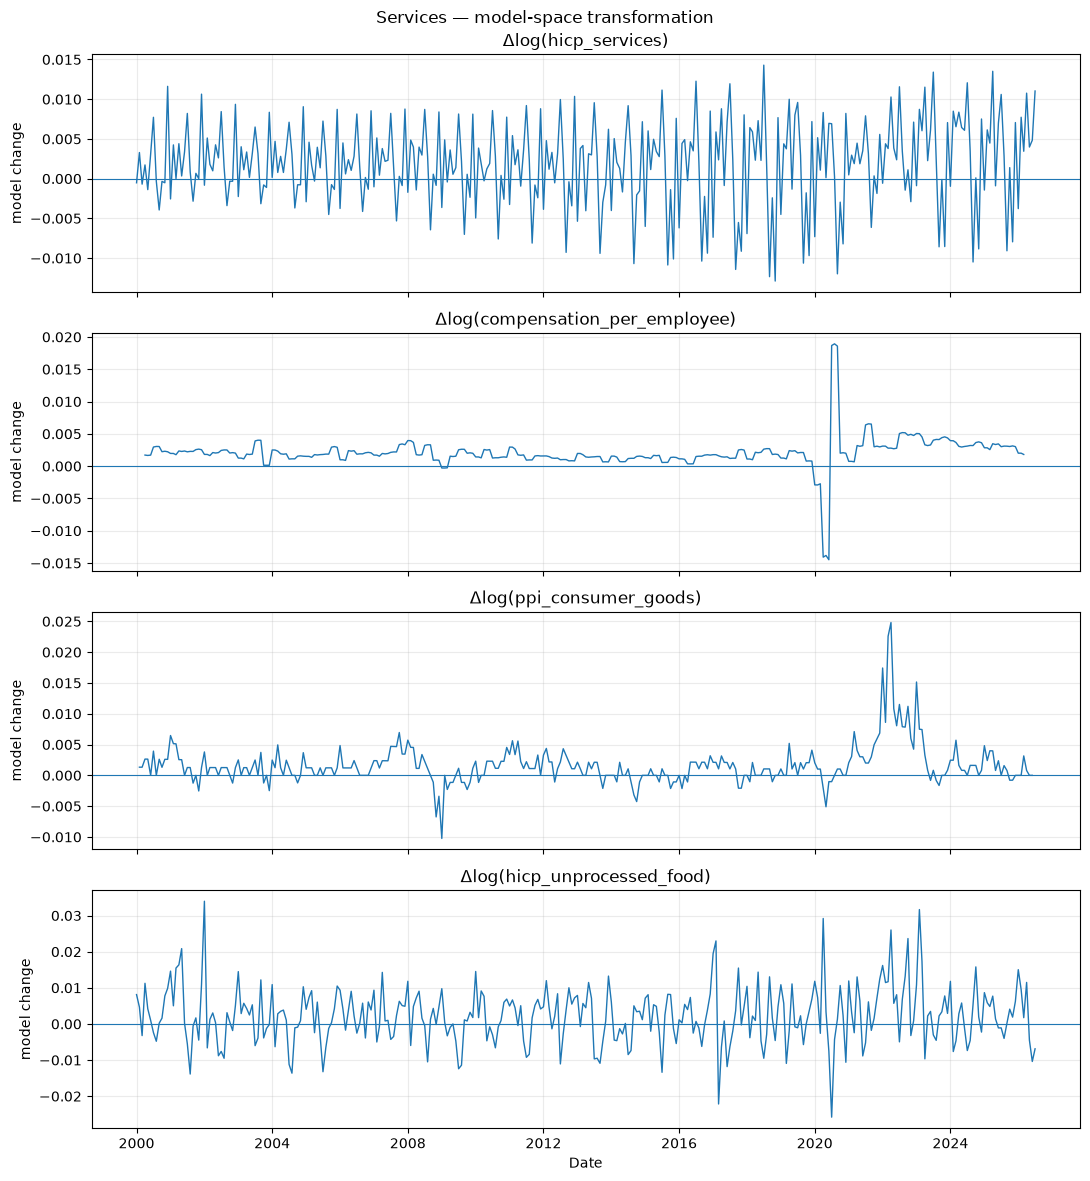

In [5]:
model_differences = native_model_differences(native_levels, COMPONENT)
transform_labels = headline_transformation_table(COMPONENT)["model_change"].to_dict()

display(model_differences.describe().T)

plot_headline_model_differences(
    model_differences,
    component_label=SPEC["label"],
    transform_labels=transform_labels,
)
plt.show()

All four native positive level/index series are mapped into log state levels. The shared engine then takes the first difference internally, so the actual BVAR variables are first log differences.

This retains the common transformation architecture:

```text
native level
    ↓ log
state level
    ↓ first difference inside shared engine
Δlog(variable)
```

## 5. Exact sparse four-variable BVAR design

In [6]:
prepared = prepare_headline_component(native_levels, COMPONENT)

print("State variables:")
for name in prepared["state_levels"].columns:
    print("  ", name)

print("Exogenous regressors:", prepared["exog"])
print("Active common endogenous lags:", SPEC["active_lags"])

assert prepared["exog"] is None
assert SPEC["active_lags"] == [1, 2, 3, 4, 5, 12]

State variables:
   state__hicp_services
   state__compensation_per_employee
   state__ppi_consumer_goods
   state__hicp_unprocessed_food
Exogenous regressors: None
Active common endogenous lags: [1, 2, 3, 4, 5, 12]


No component-specific regression logic is hidden in the notebook. The adapter sends all four transformed state-level series to `energy_bvar_model.py` together with:

```python
p = 12
active_lags = [1, 2, 3, 4, 5, 12]
```

The coefficient sampler therefore estimates all own- and cross-variable coefficients for lags 1–5 and 12 while fixing every coefficient on lags 6–11 to exactly zero.

The full 12-lag companion state is nevertheless retained for stability, DK smoothing and forecasting.

## 6. Priors

In [7]:
display(pd.Series(asdict(PRIOR_CONFIG), name="value").to_frame())
display(pd.Series(asdict(SAMPLER_CONFIG), name="value").to_frame())

,value
lambda1,2.000000e-01
lambda2,5.000000e-01
lambda3,1.000000e+00
lambda4,1.000000e+01
a_prior_var,1.000000e+01
phi_prior_mean,2.000000e-02
phi_prior_df,1.000000e+01
h0_var,4.000000e+00
outlier_mean_frequency,2.083333e-02
outlier_prior_observations,1.200000e+02


,value
reps,6000
burn,3000
thin,1
seed,42
max_stability_tries,1000
progress_every,500
sv_sampler,centered_ksc
dk_projection_mode,strict
dk_level_relative_gate,0.000001
dk_difference_relative_gate,0.000001


The Energy-suite Minnesota prior is centred on white noise for transformed variables. `lambda2` matters here because Services is genuinely multivariate: it controls cross-variable shrinkage. `lambda3` controls higher-lag decay among the coefficients that remain free.

Inactive lag blocks have a **degenerate exact-zero restriction**. They are not sampled and are not merely given a tighter prior.

## 7. Gibbs estimation

In [8]:
result = run_headline_bvar(
    prepared,
    component=COMPONENT,
    vintage=VINTAGE_USED,
    prior_config=PRIOR_CONFIG,
    sampler_config=SAMPLER_CONFIG,
    code_version="headline-services-sparse-bvar-v1",
)

print("Run ID:", result["metadata"]["run_id"])
print("Posterior draws:", result["n_draws"])
print("Variables:", result["variables"])
print("Maximum companion lag:", result["p"])
print("Active lags:", result["active_lags"])
print("Balanced estimation end:", result["prep"]["balanced_end"])
print("Last calendar date:", result["prep"]["last_calendar_date"])
print(
    "Interior-missing Gibbs augmentation:",
    result["prep"].get("requires_data_augmentation", False),
)
print(
    "Interior missing level cells:",
    result["prep"].get("n_interior_missing_level_cells", 0),
)
print(
    "Trailing ragged-edge months handled in the forecast/nowcast DK step:",
    len(
        result["prep"]["levels"].index[
            result["prep"]["levels"].index > result["prep"]["balanced_end"]
        ]
    ),
)

iteration 500/6,000 | B instability rejection 0.79% | radius 0.9761
iteration 1,000/6,000 | B instability rejection 0.70% | radius 0.9897
iteration 1,500/6,000 | B instability rejection 0.86% | radius 0.9855
iteration 2,000/6,000 | B instability rejection 0.70% | radius 0.9883
iteration 2,500/6,000 | B instability rejection 0.75% | radius 0.9891
iteration 3,000/6,000 | B instability rejection 0.66% | radius 0.9875
iteration 3,500/6,000 | B instability rejection 0.65% | radius 0.9982
iteration 4,000/6,000 | B instability rejection 0.74% | radius 0.9696
iteration 4,500/6,000 | B instability rejection 0.73% | radius 0.9818
iteration 5,000/6,000 | B instability rejection 0.70% | radius 0.9877
iteration 5,500/6,000 | B instability rejection 0.67% | radius 0.9875
iteration 6,000/6,000 | B instability rejection 0.65% | radius 0.9810
Run ID: 826b60db51f9c7e7aa180f2d0c0b4173e8f65426ab02d3d03d2348184d23bae1
Posterior draws: 3000
Variables: ['state__hicp_services', 'state__compensation_per_employ

## 8. Hard audit of the sparse common-lag restriction

In [9]:
lag_audit = sparse_lag_restriction_table(result)
display(lag_audit)

inactive = [6, 7, 8, 9, 10, 11]
assert lag_audit.loc[inactive, "max_abs_posterior_coefficient"].max() == 0.0
assert set(result["active_lags"]) == {1, 2, 3, 4, 5, 12}

print("PASS — lags 6–11 are exactly zero in all equations and all retained draws.")

,status,max_abs_posterior_coefficient
lag,,
1,estimated,1.022439
2,estimated,0.513087
3,estimated,0.397636
4,estimated,0.317432
5,estimated,0.255715
6,fixed_zero,0.000000
7,fixed_zero,0.000000
8,fixed_zero,0.000000
9,fixed_zero,0.000000


PASS — lags 6–11 are exactly zero in all equations and all retained draws.


This is stronger than a posterior interval containing zero. The omitted lag blocks are absent from the Gaussian coefficient draw and are reconstructed as exact zeros before stability testing.

## 9. Posterior coefficients

,prior_mean,prior_sd,posterior_mean,posterior_median,posterior_sd,q05,q16,q84,q95,ESS
state__hicp_services: const,0.00,0.05,1.91 × 10⁻³,1.92 × 10⁻³,4.22 × 10⁻⁴,1.21 × 10⁻³,1.49 × 10⁻³,2.33 × 10⁻³,2.60 × 10⁻³,1553.50
state__hicp_services: state__hicp_services L1,0.00,0.20,-0.14,-0.14,0.05,-0.22,-0.19,-0.09,-0.06,2353.86
state__hicp_services: state__compensation_per_employee L1,0.00,0.26,-0.07,-0.07,0.11,-0.24,-0.17,0.04,0.10,2877.34
state__hicp_services: state__ppi_consumer_goods L1,0.00,0.23,0.05,0.05,0.09,-0.10,-0.04,0.14,0.20,2245.69
state__hicp_services: state__hicp_unprocessed_food L1,0.00,0.07,-1.82 × 10⁻³,-1.97 × 10⁻³,0.03,-0.05,-0.03,0.03,0.05,2634.58
state__hicp_services: state__hicp_services L2,0.00,0.10,0.06,0.06,0.05,-0.01,0.02,0.11,0.14,2098.39
state__hicp_services: state__compensation_per_employee L2,0.00,0.13,-0.16,-0.16,0.09,-0.31,-0.25,-0.07,-2.75 × 10⁻³,2433.02
state__hicp_services: state__ppi_consumer_goods L2,0.00,0.12,-8.72 × 10⁻³,-0.01,0.08,-0.14,-0.08,0.07,0.12,3000.00
state__hicp_services: state__hicp_unprocessed_food L2,0.00,0.04,0.11,0.11,0.02,0.07,0.08,0.13,0.15,2582.11
state__hicp_services: state__hicp_services L3,0.00,0.07,-0.15,-0.15,0.04,-0.22,-0.19,-0.11,-0.08,2833.17


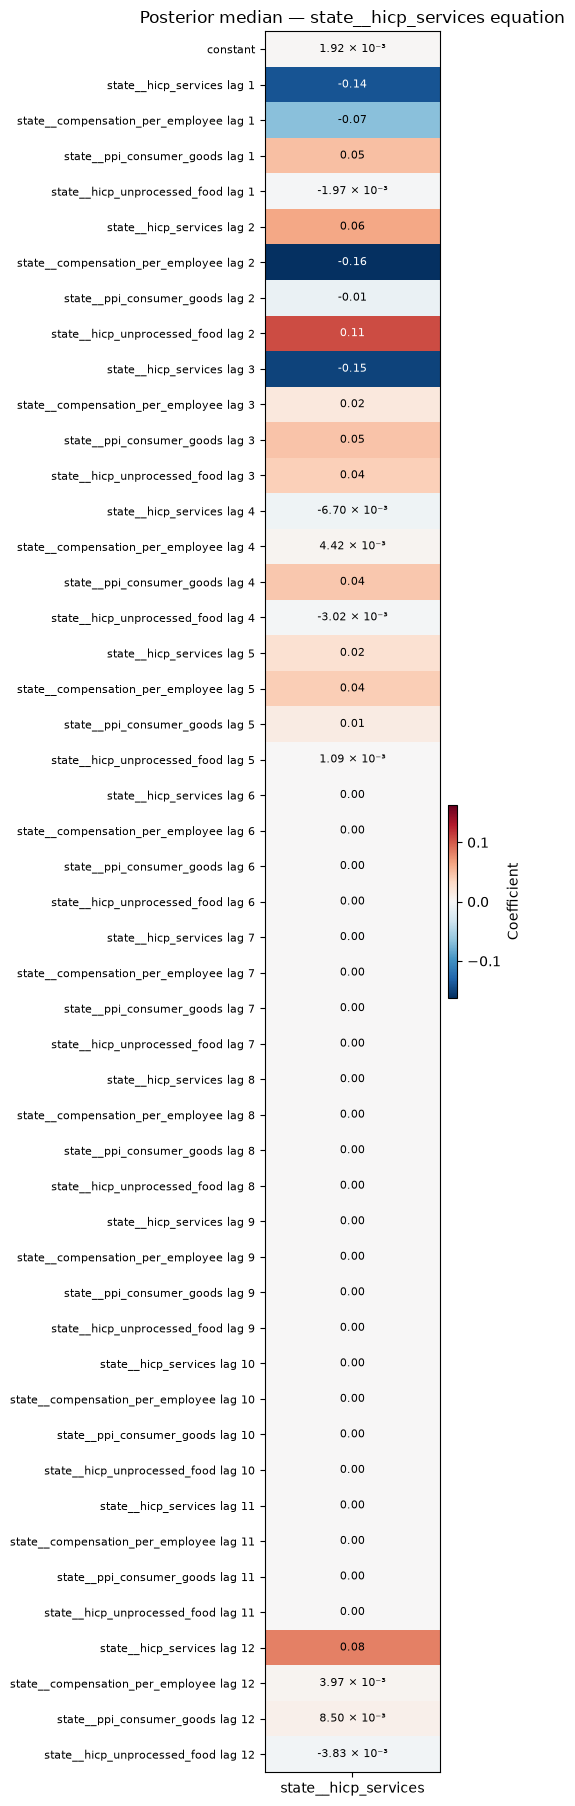

In [10]:
coef = coefficient_posterior_table(result)

services_equation = coef.loc[
    coef.index.str.startswith("state__hicp_services:")
]
display(
    style_numeric_table(
        services_equation,
        caption="Services equation — posterior coefficients",
    )
)

plot_coefficient_heatmap(result, equation="state__hicp_services")
plt.show()

Because the BVAR has four equations, the Services equation includes own- and cross-lag coefficients from all four variables at the active lags. The complete coefficient table remains available through `coefficient_posterior_table(result)`; the notebook displays the Services equation first because it is the forecast target.

## 10. Stochastic volatility, outliers and residual diagnostics

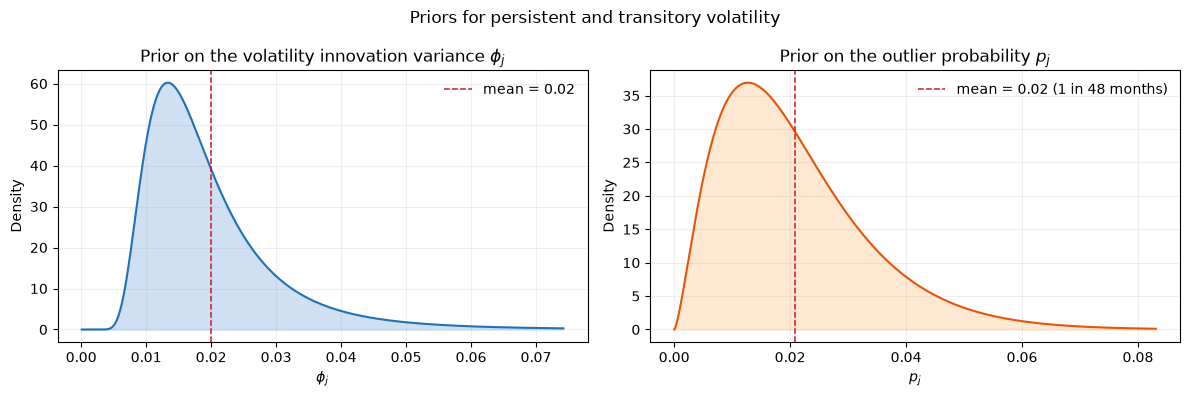

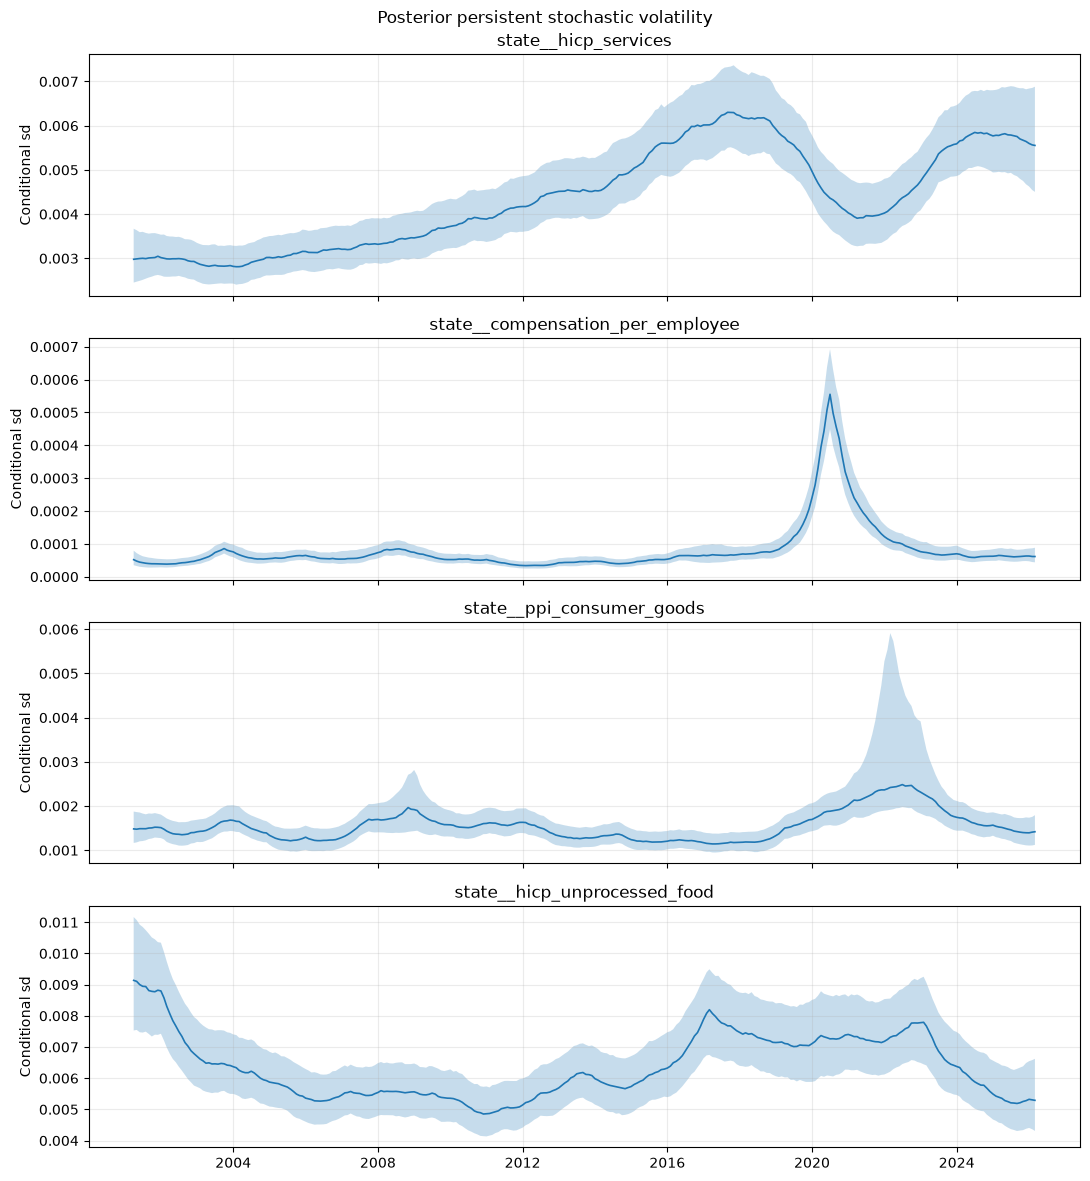

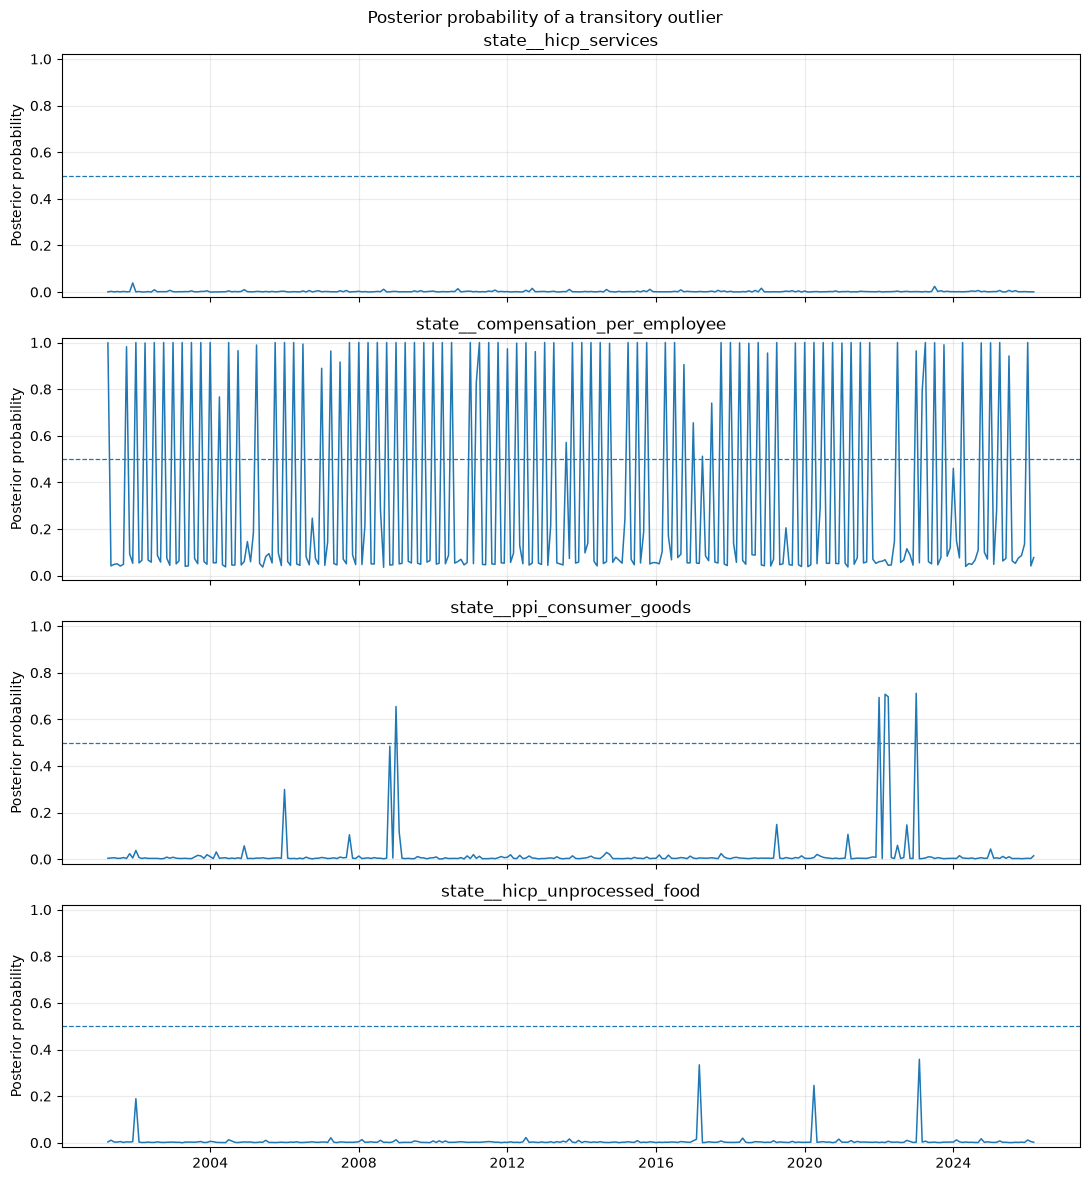

,mean,sd,skewness,excess_kurtosis,acf_1,maximum_absolute
variable,,,,,,
state__hicp_services,-0.01,0.97,-0.11,-0.19,-0.02,2.45
state__compensation_per_employee,0.01,0.87,-0.06,-0.13,-0.09,3.02
state__ppi_consumer_goods,0.03,0.97,0.24,0.32,0.04,3.41
state__hicp_unprocessed_food,0.01,0.99,0.13,0.52,-0.02,3.40


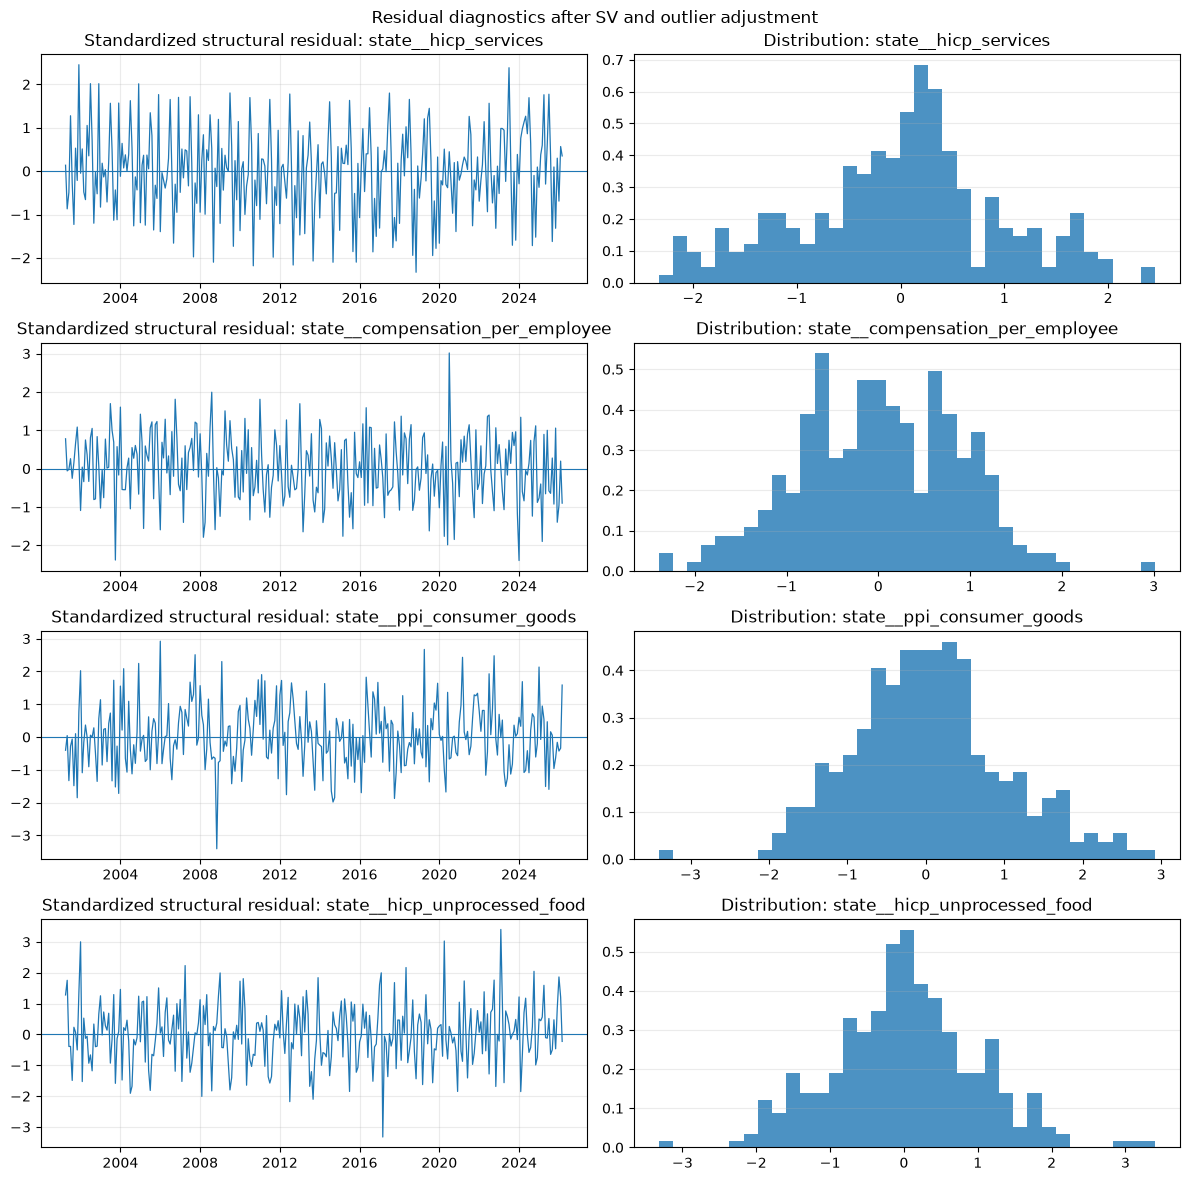

In [11]:
plot_phi_and_outlier_priors(result["prior"])
plt.show()

plot_posterior_volatility(result, include_outliers=False)
plt.show()

plot_outlier_probabilities(result)
plt.show()

residual_diag = residual_diagnostic_table(result)
display(style_numeric_table(residual_diag, caption="Residual diagnostics"))

plot_standardized_residuals(result)
plt.show()

## 11. DK ragged-edge nowcast for endogenous auxiliary variables

This is an important difference from Processed Food and NEIG.

There, wages/PPI were exogenous regressors and their trailing edge required an explicit conditioning rule. Here they are **endogenous BVAR variables**. If the target HICP is observed through July while wages stop in March and PPI in June, the missing wage/PPI levels are latent states.

The same DK machinery used by the Energy suite therefore jointly draws those missing values inside the multivariate system.

In [12]:
# A forecast call also returns the stochastic ragged-edge path before the true future horizon.
baseline = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    n_draws=min(FORECAST_DRAWS, result["n_draws"]),
    simulate_future_outliers=True,
    seed=2026,
)

native_nowcast = headline_native_nowcast_summary_table(
    baseline,
    native_levels,
    missing_only=True,
)
display(native_nowcast)

print("Ragged-edge dates:", list(baseline["path_dates"][: baseline["tail_length"]]))

observed_native         q05         q16  \
date       variable                                                             
2026-04-01 compensation_per_employee              NaN  127.560625  127.694710   
2026-05-01 compensation_per_employee              NaN  127.623832  127.875383   
2026-06-01 compensation_per_employee              NaN  127.697641  128.061546   
2026-07-01 compensation_per_employee              NaN  127.710650  128.217453   
           ppi_consumer_goods                     NaN  126.827662  127.001205   

                                             q50         q84         q95  
date       variable                                                       
2026-04-01 compensation_per_employee  127.715427  127.727117  127.746390  
2026-05-01 compensation_per_employee  127.947946  127.985012  128.058671  
2026-06-01 compensation_per_employee  128.194020  128.268281  128.435290  
2026-07-01 compensation_per_employee  128.435711  128.567542  128.813936  
           ppi_consumer_goods         127.209976  127.389286  127.555222

Ragged-edge dates: [Timestamp('2026-04-01 00:00:00'), Timestamp('2026-05-01 00:00:00'), Timestamp('2026-06-01 00:00:00'), Timestamp('2026-07-01 00:00:00')]


Observed HICP Services and observed unprocessed-food levels in the ragged edge are conditioning observations, not forecasts. Only genuinely missing cells should appear in the `native_nowcast` table.

## 12. Unconditional joint BVAR forecast

In [13]:
print("HICP Services index")
display(headline_forecast_horizon_table(baseline, kind="level"))

print("HICP Services YoY inflation")
display(headline_forecast_horizon_table(baseline, kind="yoy"))

HICP Services index


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,103.668674,104.096203,104.706389,105.350139,105.801697
3,2026-10-01,102.969034,103.743842,104.712378,105.699012,106.456937
6,2027-01-01,103.115784,103.972835,105.287888,106.600105,107.726793
12,2027-07-01,103.135992,104.663119,106.750837,108.662601,110.482772
18,2028-01-01,103.461617,105.234717,107.725715,110.411578,112.818060


HICP Services YoY inflation


,target_date,q05,q16,median,q84,q95
months_ahead,,,,,,
1,2026-08-01,1.865652,2.285745,2.885319,3.517872,3.961577
3,2026-10-01,1.959633,2.726846,3.685887,4.662849,5.413344
6,2027-01-01,2.582355,3.434974,4.743223,6.048652,7.169512
12,2027-07-01,-1.597184,-0.140140,1.851767,3.675795,5.412434
18,2028-01-01,-1.165293,0.519694,2.398020,4.308676,5.983805


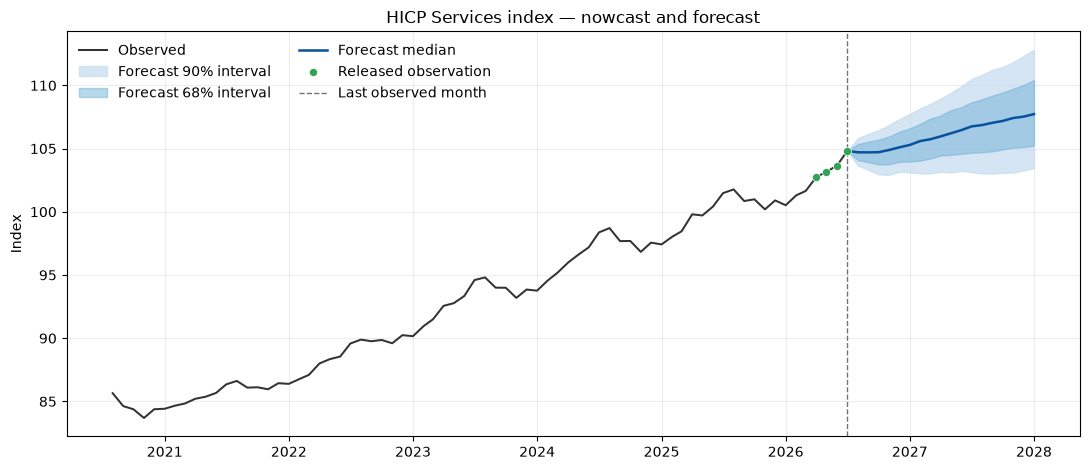

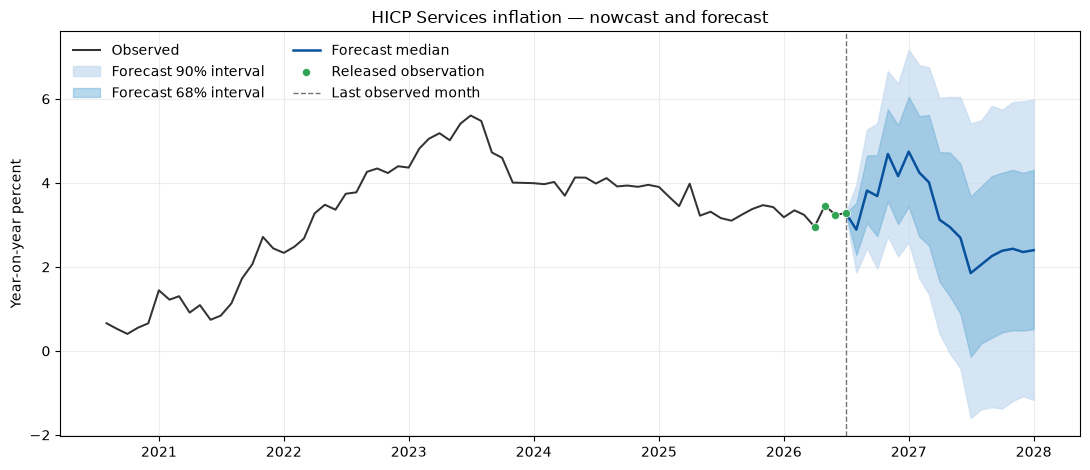

In [14]:
plot_headline_hicp_forecast_fan(baseline, kind="level", last_obs=72)
plt.show()

plot_headline_hicp_forecast_fan(baseline, kind="yoy", last_obs=72)
plt.show()

Unlike the Processed Food and NEIG single equations, this forecast can be genuinely **unconditional**: all four variables are endogenous and are forecast jointly.

That is the natural production baseline when no external assumptions are supplied.

## 13. Paper-style conditional forecasting interface

WP374 evaluates the Services model conditionally: wages and PPI consumer goods are conditioned on observed historical future values, while unprocessed food is supplied by the separately selected Unprocessed Food model.

In real-time production we cannot condition on unknown future realised wages/PPI. We therefore keep the unconditional BVAR as the default. However, the exact same forecast engine allows the dashboard to impose native-level paths whenever an assumption or upstream component forecast is available.

The adapter keeps this interface entirely in native units:

```python
native_level_conditions={
    "compensation_per_employee": ...,
    "ppi_consumer_goods": ...,
    "hicp_unprocessed_food": ...,
}
```

The dashboard never needs to know that the state system operates in log levels.

In [15]:
# Example of the reusable cross-model bridge.
# If `unprocessed_food_forecast` is the forecast object produced by notebook 11:
#
# uf_condition = headline_native_condition_path(
#     unprocessed_food_forecast,
#     "hicp_unprocessed_food",
#     quantile=0.50,
# )
#
# services_linked = forecast_headline_component(
#     result,
#     component=COMPONENT,
#     H=FORECAST_HORIZON,
#     native_levels=native_levels,
#     native_level_conditions={
#         "hicp_unprocessed_food": uf_condition.to_numpy(),
#     },
#     n_draws=min(FORECAST_DRAWS, result["n_draws"]),
#     seed=2026,
# )
#
# This reproduces the WP374 hierarchy without duplicating transformations
# or forecast logic inside the dashboard.
print("Cross-model condition helper is ready:", headline_native_condition_path)

Cross-model condition helper is ready: <function headline_native_condition_path at 0x000001DB7381F420>


## 14. Conditional path sensitivities and WP374 response benchmarks

WP374 reports the following cumulative effects on annual Services inflation:

- +1% wages: **+0.09 p.p. after 2 months**, **+0.24 p.p. after 6 months**;
- +1% PPI consumer goods: **+0.09 p.p. after 6 months**;
- +1% unprocessed-food prices: **+0.07 p.p. after 6 months**.

Our modern model differs in sample, priors, stochastic volatility and outlier treatment, so these are **economic plausibility benchmarks**, not equality targets.

For a clean scenario comparison, we first extract each driver's posterior-median unconditional path. The baseline-conditioned run fixes that path; the scenario-conditioned run fixes the same path multiplied by 1.01. Both runs use identical posterior/random seeds and suppress future outliers so the difference isolates the changed condition as closely as possible.

In [16]:
display(wp374_services_response_benchmark_table())

N_SCENARIO_DRAWS = min(FORECAST_DRAWS, result["n_draws"])

wage_path = headline_native_condition_path(
    baseline, "compensation_per_employee", quantile=0.50
)
ppi_path = headline_native_condition_path(
    baseline, "ppi_consumer_goods", quantile=0.50
)
uf_path = headline_native_condition_path(
    baseline, "hicp_unprocessed_food", quantile=0.50
)

change  \
driver                    horizon_months              
compensation_per_employee 2               +1% level   
                          6               +1% level   
ppi_consumer_goods        6               +1% level   
hicp_unprocessed_food     6               +1% level   

                                          published_service_inflation_effect_pp  
driver                    horizon_months                                         
compensation_per_employee 2                                                0.09  
                          6                                                0.24  
ppi_consumer_goods        6                                                0.09  
hicp_unprocessed_food     6                                                0.07

,target_date,modern_median_pp,modern_q16_pp,modern_q84_pp,WP374_published_pp
months_ahead,,,,,
2,2026-09-01,-0.31288,-2.408994,1.613696,0.09
6,2027-01-01,-0.34826,-2.254784,1.608083,0.24


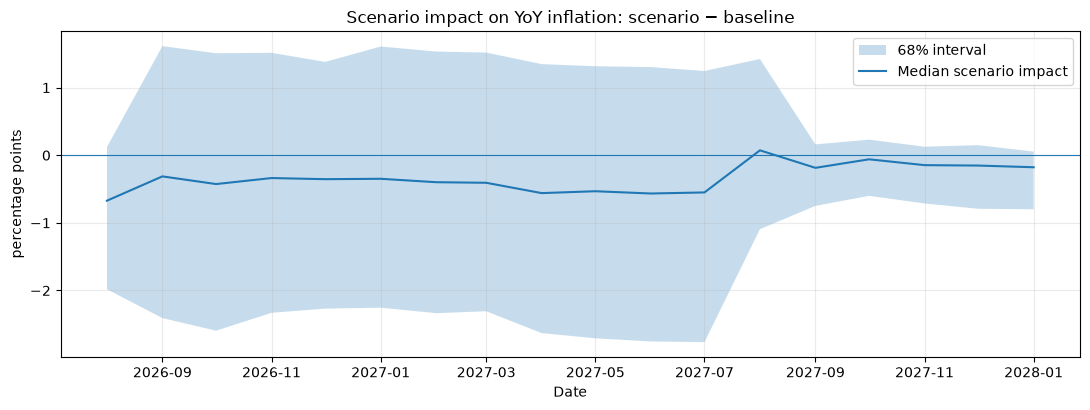

In [17]:
# Wages: baseline median path vs +1%.
wage_base = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    native_level_conditions={
        "compensation_per_employee": wage_path.to_numpy(),
    },
    n_draws=N_SCENARIO_DRAWS,
    simulate_future_outliers=False,
    seed=801,
)
wage_plus1 = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    native_level_conditions={
        "compensation_per_employee": wage_path.to_numpy() * 1.01,
    },
    n_draws=N_SCENARIO_DRAWS,
    simulate_future_outliers=False,
    seed=801,
)

display(
    compare_services_scenario_to_wp374(
        wage_base,
        wage_plus1,
        driver="compensation_per_employee",
        horizons=(2, 6),
    )
)
plot_headline_scenario_impact(wage_base, wage_plus1, kind="yoy")
plt.show()

,target_date,modern_median_pp,modern_q16_pp,modern_q84_pp,WP374_published_pp
months_ahead,,,,,
6,2027-01-01,0.020705,-0.181536,0.164066,0.09


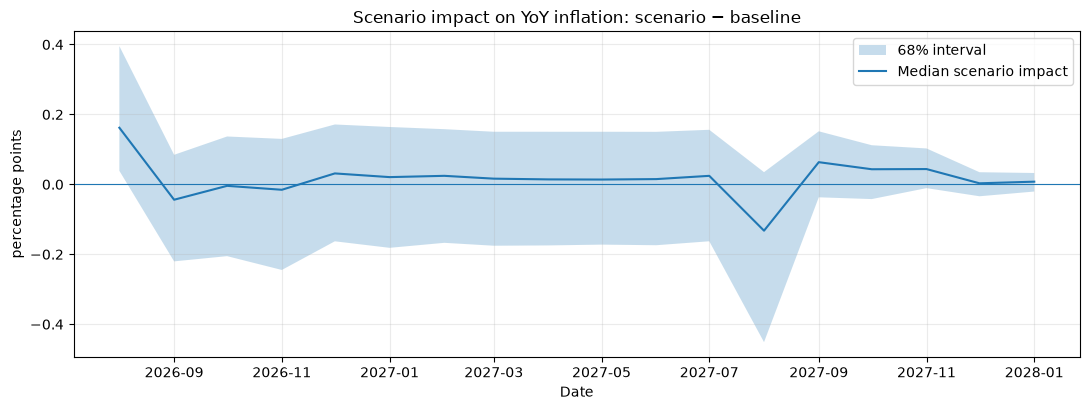

In [18]:
# PPI consumer goods: baseline median path vs +1%.
ppi_base = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    native_level_conditions={
        "ppi_consumer_goods": ppi_path.to_numpy(),
    },
    n_draws=N_SCENARIO_DRAWS,
    simulate_future_outliers=False,
    seed=802,
)
ppi_plus1 = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    native_level_conditions={
        "ppi_consumer_goods": ppi_path.to_numpy() * 1.01,
    },
    n_draws=N_SCENARIO_DRAWS,
    simulate_future_outliers=False,
    seed=802,
)

display(
    compare_services_scenario_to_wp374(
        ppi_base,
        ppi_plus1,
        driver="ppi_consumer_goods",
        horizons=(6,),
    )
)
plot_headline_scenario_impact(ppi_base, ppi_plus1, kind="yoy")
plt.show()

,target_date,modern_median_pp,modern_q16_pp,modern_q84_pp,WP374_published_pp
months_ahead,,,,,
6,2027-01-01,-0.06977,-0.231625,0.039269,0.07


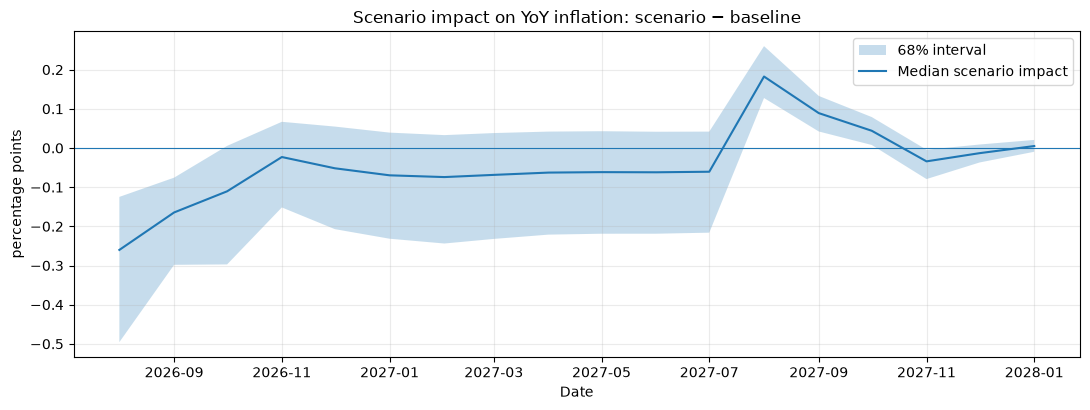

In [19]:
# Unprocessed food: baseline median path vs +1%.
uf_base = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    native_level_conditions={
        "hicp_unprocessed_food": uf_path.to_numpy(),
    },
    n_draws=N_SCENARIO_DRAWS,
    simulate_future_outliers=False,
    seed=803,
)
uf_plus1 = forecast_headline_component(
    result,
    component=COMPONENT,
    H=FORECAST_HORIZON,
    native_levels=native_levels,
    native_level_conditions={
        "hicp_unprocessed_food": uf_path.to_numpy() * 1.01,
    },
    n_draws=N_SCENARIO_DRAWS,
    simulate_future_outliers=False,
    seed=803,
)

display(
    compare_services_scenario_to_wp374(
        uf_base,
        uf_plus1,
        driver="hicp_unprocessed_food",
        horizons=(6,),
    )
)
plot_headline_scenario_impact(uf_base, uf_plus1, kind="yoy")
plt.show()

These exercises should be interpreted as **conditional-path sensitivities**, not structural shocks. The BVAR contains contemporaneously correlated innovations, and the Energy-suite structural covariance decomposition is not the same identification device used to define an economically labelled wage or PPI shock.

## 15. MCMC and stability diagnostics

,posterior_mean,posterior_sd,ESS,MCSE_mean,MCSE_over_sd
log likelihood,6031.31,17.17,195.14,1.23,0.07
spectral radius,0.98,6.56 × 10⁻³,870.10,2.22 × 10⁻⁴,0.03
"A[state__compensation_per_employee,state__hicp_services]",7.81 × 10⁻⁴,2.07 × 10⁻³,241.91,1.33 × 10⁻⁴,0.06
phi[state__hicp_services],0.01,4.84 × 10⁻³,86.65,5.20 × 10⁻⁴,0.11
p_outlier[state__hicp_services],7.79 × 10⁻³,4.95 × 10⁻³,1665.95,1.21 × 10⁻⁴,0.02
own L1[state__hicp_services],-0.14,0.05,2353.86,1.06 × 10⁻³,0.02
phi[state__compensation_per_employee],0.09,0.03,88.84,3.31 × 10⁻³,0.11
p_outlier[state__compensation_per_employee],0.25,0.02,978.88,7.85 × 10⁻⁴,0.03
own L1[state__compensation_per_employee],1.00,7.75 × 10⁻³,1102.11,2.33 × 10⁻⁴,0.03
phi[state__ppi_consumer_goods],0.03,0.02,12.04,7.14 × 10⁻³,0.29


,value
retained_draws,3000.000000
median_spectral_radius,0.984779
q95_spectral_radius,0.995068
maximum_spectral_radius,0.999995
retained_unstable_share,0.000000
B_total_proposals,6039.000000
B_unstable_proposals,39.000000
B_instability_rejection_rate,0.006458


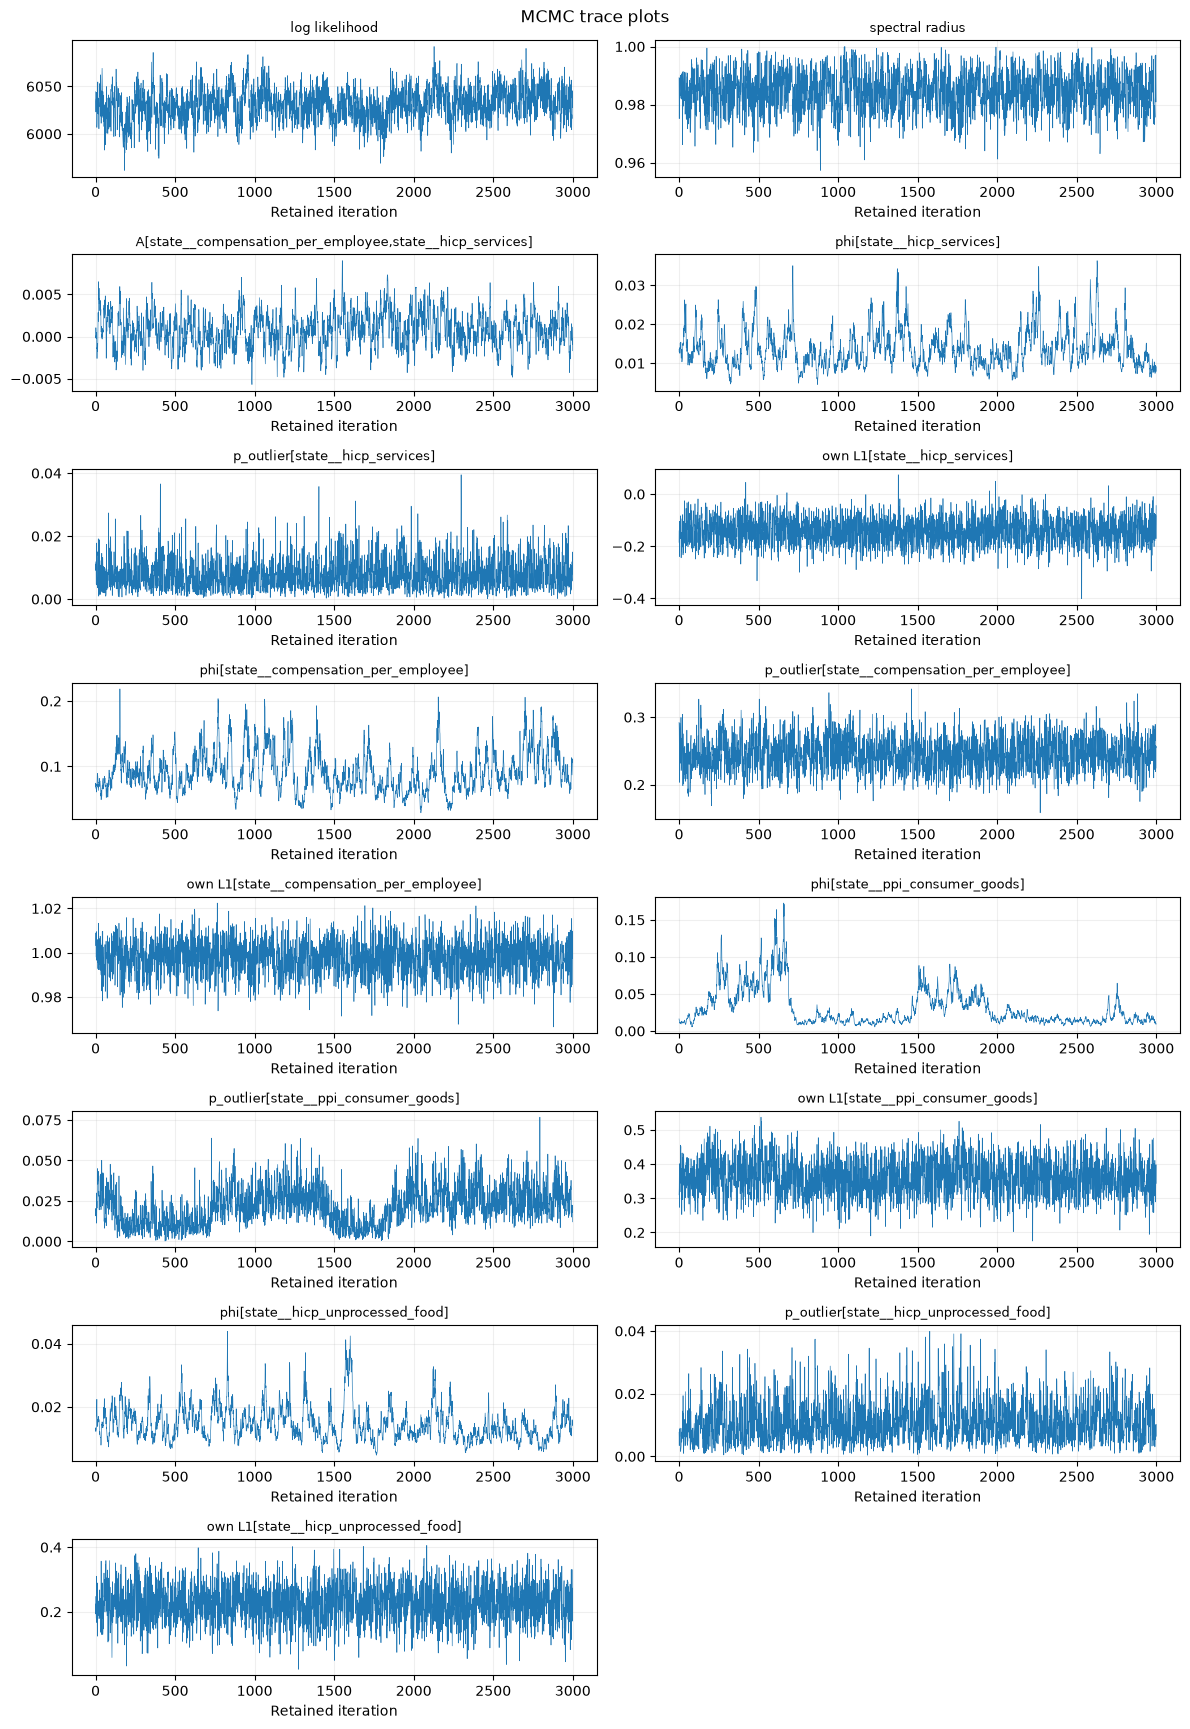

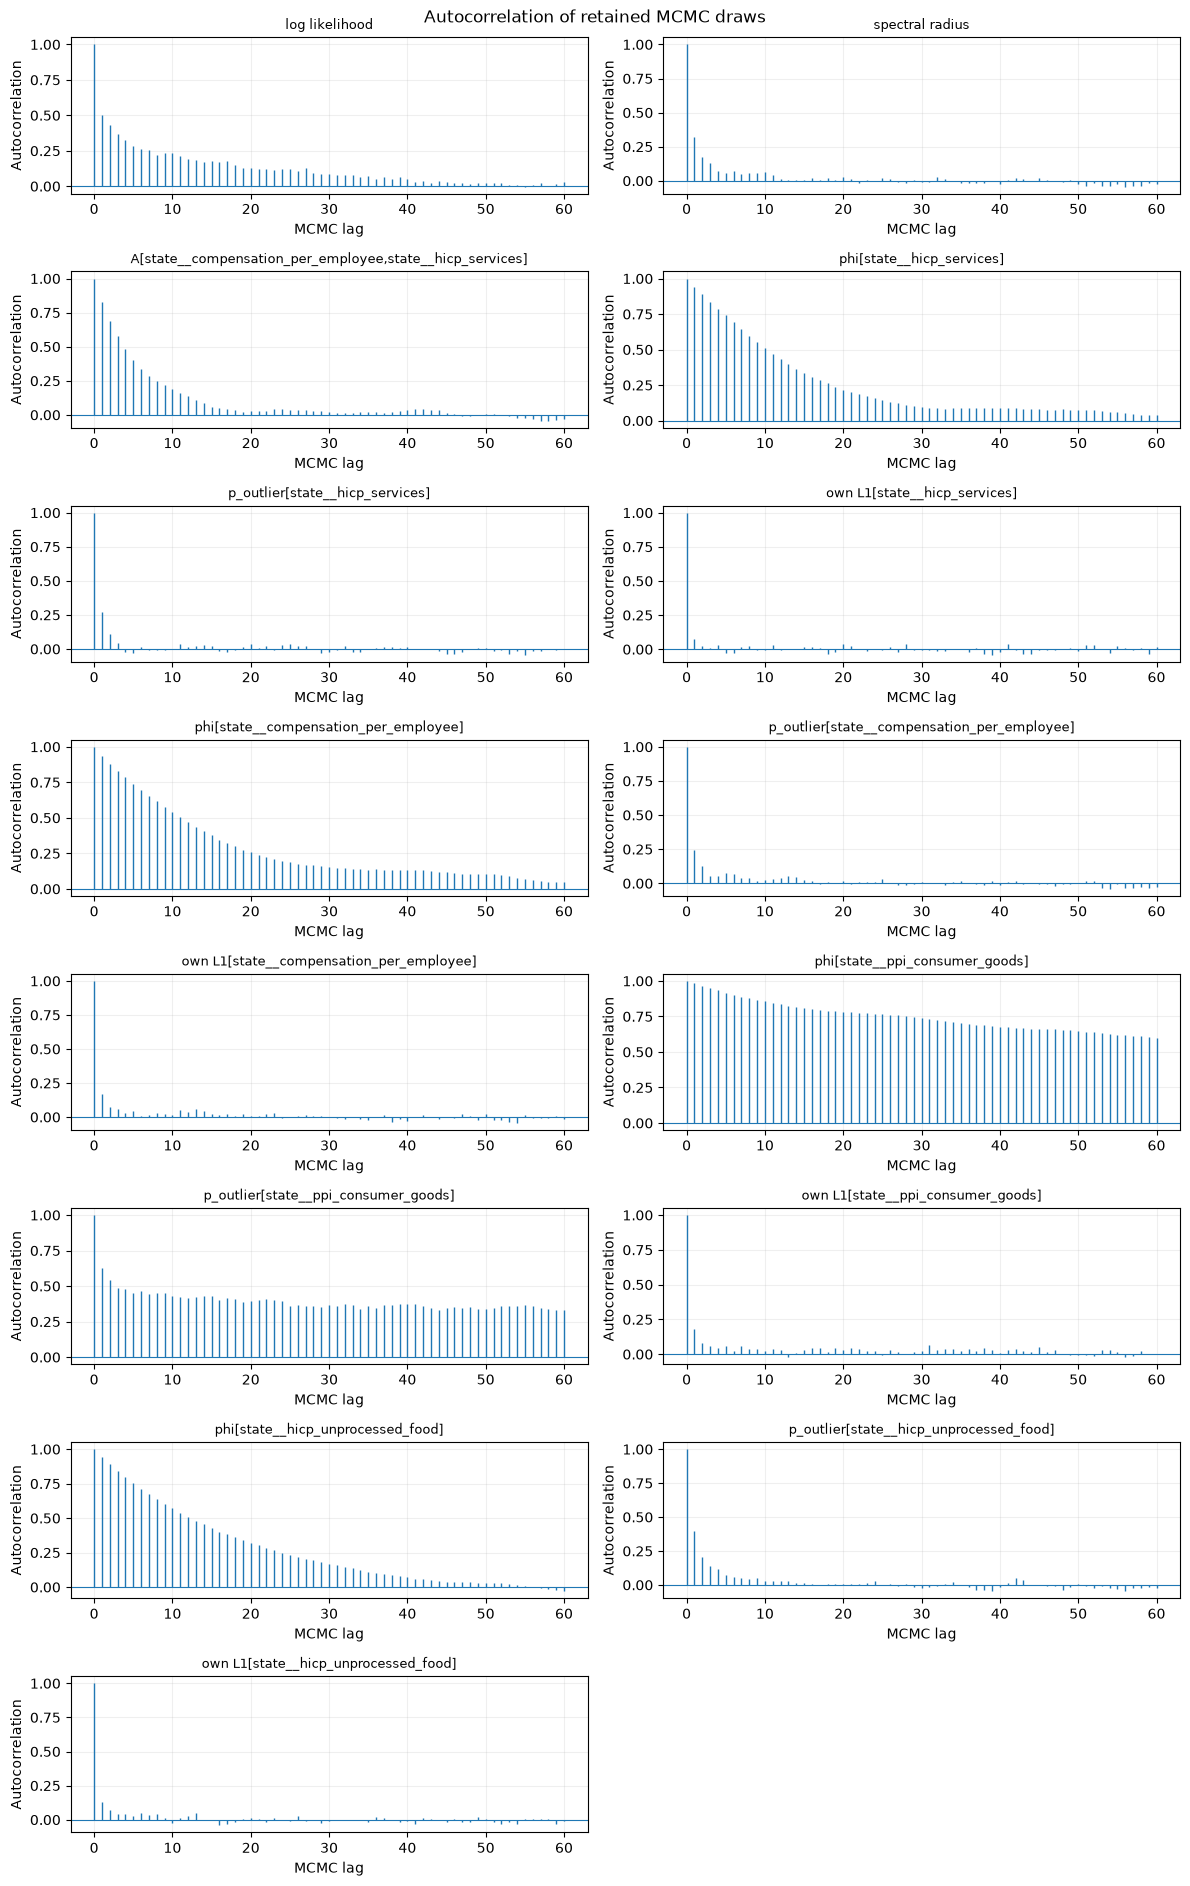

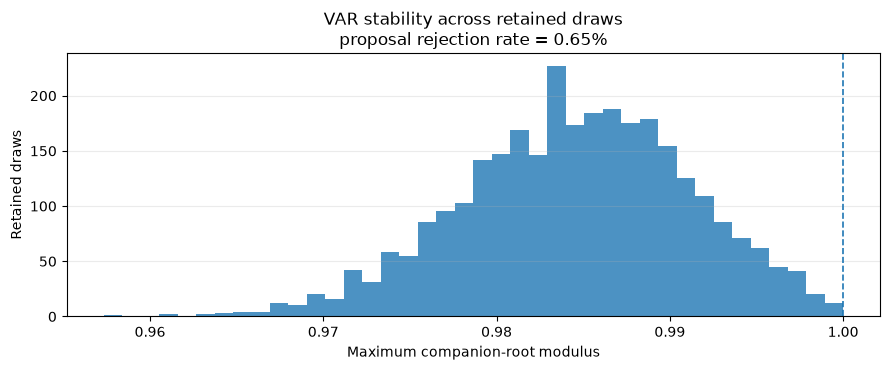

In [20]:
display(style_numeric_table(mcmc_diagnostics(result), caption="MCMC diagnostics"))
display(stability_diagnostics(result).to_frame("value"))

plot_trace_grid(result)
plt.show()

plot_chain_acf_grid(result)
plt.show()

plot_spectral_radius(result)
plt.show()

## 16. Stationarity diagnostics

In [21]:
transformed = native_model_differences(native_levels, COMPONENT)

# Use only rows jointly observed in the raw transformed panel.
# DK data augmentation remains part of the Bayesian model, not of these tests.
display(stationarity_tests(transformed.dropna()))

,ADF statistic,ADF p-value,ADF lags,KPSS statistic,KPSS p-value,KPSS lags,observations
variable,,,,,,,
hicp_services,-1.806990,0.376997,14,0.372914,0.08883,11,297
compensation_per_employee,-3.111812,0.025691,12,0.451841,0.05481,4,299
ppi_consumer_goods,-4.019495,0.001312,13,0.267796,0.10000,10,298
hicp_unprocessed_food,-3.757926,0.003368,16,0.214245,0.10000,1,295


## 17. Posterior predictive checks

,observed,replicated_median,replicated_q05,replicated_q95
state__hicp_services: mean,1.82 × 10⁻³,1.87 × 10⁻³,1.17 × 10⁻³,2.71 × 10⁻³
state__hicp_services: sd,5.44 × 10⁻³,5.13 × 10⁻³,4.55 × 10⁻³,6.85 × 10⁻³
state__hicp_services: maximum_absolute,0.01,0.02,0.02,0.07
state__compensation_per_employee: mean,2.06 × 10⁻³,9.31 × 10⁻⁴,-3.51 × 10⁻³,5.18 × 10⁻³
state__compensation_per_employee: sd,2.63 × 10⁻³,3.88 × 10⁻³,1.91 × 10⁻³,8.38 × 10⁻³
state__compensation_per_employee: maximum_absolute,0.02,0.02,7.02 × 10⁻³,0.03
state__ppi_consumer_goods: mean,1.61 × 10⁻³,7.93 × 10⁻⁴,-1.22 × 10⁻³,2.40 × 10⁻³
state__ppi_consumer_goods: sd,3.28 × 10⁻³,3.85 × 10⁻³,2.34 × 10⁻³,6.73 × 10⁻³
state__ppi_consumer_goods: maximum_absolute,0.02,0.03,0.01,0.08
state__hicp_unprocessed_food: mean,2.26 × 10⁻³,1.69 × 10⁻³,-9.22 × 10⁻⁴,3.39 × 10⁻³


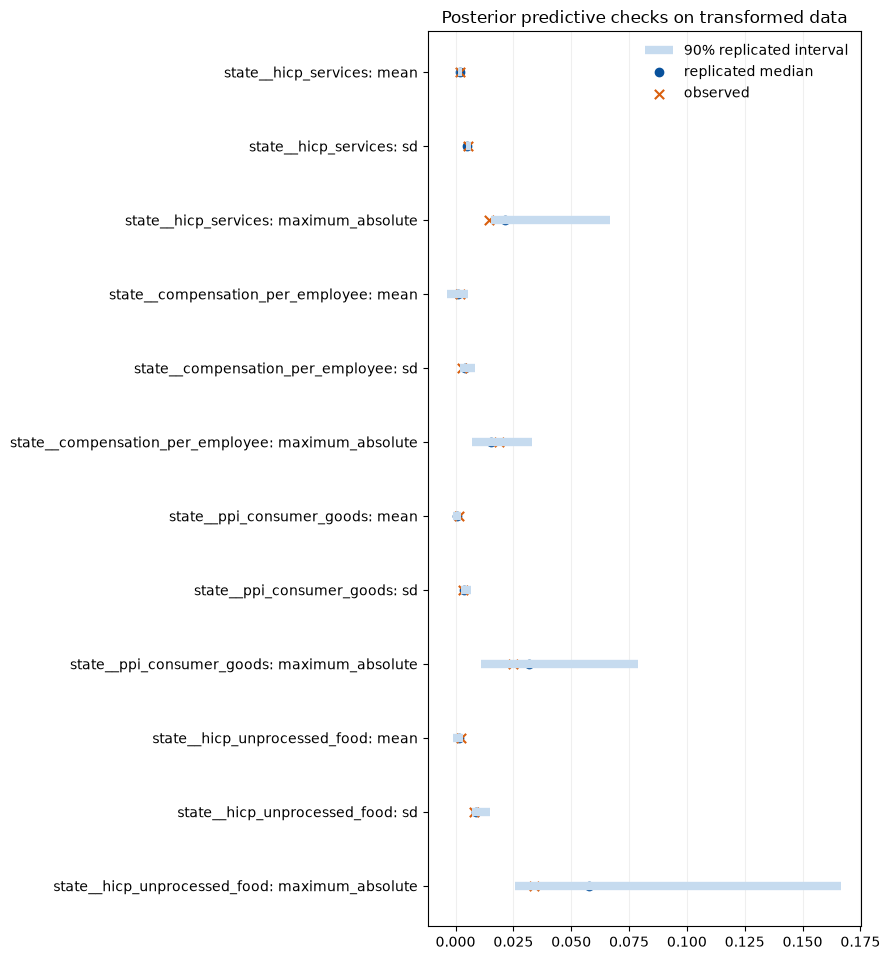

In [22]:
ppc_summary, ppc_draws = posterior_predictive_statistics(
    result,
    n_draws=min(300, result["n_draws"]),
    seed=321,
)

display(style_numeric_table(ppc_summary, caption="Posterior predictive checks"))
plot_posterior_predictive_check(ppc_summary)
plt.show()

## 18. Save / common registry promotion

In [ ]:
if SAVE_RESULTS:
    if save_energy_bvar_result is None:
        raise RuntimeError("energy_bvar_io.save_energy_bvar_result is unavailable.")
    saved = save_energy_bvar_result(result, PROJECT_ROOT / "results")
    print("Saved to:", saved["directory"])
else:
    print("SAVE_RESULTS=False — estimation is not promoted to the common registry.")

SAVE_RESULTS=False — estimation is not promoted to the common registry.


: 

## Production contract

```text
services_monthly.csv
    │
    ├─ hicp_services
    ├─ compensation_per_employee
    ├─ ppi_consumer_goods
    └─ hicp_unprocessed_food
            │
            └─ all four: native positive level → log state → Δlog
                         all ENDOGENOUS
                         common active lags {1,2,3,4,5,12}
                         lags 6–11 fixed exactly to zero
                         no seasonal dummies
                            ↓
               shared Energy Bayesian engine
                            ↓
                Minnesota + SV + outliers
                DK ragged-edge augmentation
                            ↓
              unconditional joint forecast
                    or native-level
                conditional forecast paths
                            ↓
                  Services HICP draws
                  Services YoY draws
                            ↓
      Headline draw-by-draw aggregation → dashboard
```

The Services BVAR is now the first Headline model where the multivariate DK machinery is used directly for **non-target ragged-edge variables**. This is exactly why the shared Energy architecture is useful rather than maintaining a separate forecasting engine for each HICP component.